Dataset source: https://github.com/SusmitSekharBhakta/Stock-market-price-prediction/blob/main/final_data_adj.csv

In [19]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.stattools import acf, pacf

SEED_VALUE = 1234
np.random.seed(SEED_VALUE)
import random
random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

In [2]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [43]:
df = pd.read_csv("../dataset/forecasting/stock_prices.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,RSI,MACD,MACDsig,MACDhist,SMA,CCI,Aroon Up,Aroon Down,Sadj
0,2017-08-28,9907.150391,9925.750000,9882.000000,9912.799805,9912.799805,159600.0,55.406997,28.647258,28.317577,0.515867,12759.905212,24.363507,0.0,0.0,NaN
1,2017-08-29,9886.400391,9887.349609,9783.750000,9796.049805,9796.049805,173300.0,55.406997,28.647258,28.317577,0.515867,12759.905212,24.363507,0.0,0.0,162.055635
2,2017-08-30,9859.500000,9909.450195,9850.799805,9884.400391,9884.400391,157800.0,55.406997,28.647258,28.317577,0.515867,12759.905212,24.363507,0.0,0.0,-22.453545
3,2017-08-31,9905.700195,9925.099609,9856.950195,9917.900391,9917.900391,327700.0,55.406997,28.647258,28.317577,0.515867,12759.905212,24.363507,0.0,0.0,-9.197608
4,2017-09-01,9937.650391,9983.450195,9909.849609,9974.400391,9974.400391,157800.0,55.406997,28.647258,28.317577,0.515867,12759.905212,24.363507,0.0,0.0,5259.919641


## Simple EDA

In [4]:
df.shape

(1825, 16)

In [5]:
pd.to_datetime(df['Date']).describe()

count                   1825
mean     2020-02-26 00:00:00
min      2017-08-28 00:00:00
25%      2018-11-27 00:00:00
50%      2020-02-26 00:00:00
75%      2021-05-27 00:00:00
max      2022-08-26 00:00:00
Name: Date, dtype: object

In [6]:
df['Date'].value_counts()

Date
2017-08-28    1
2021-01-05    1
2021-01-03    1
2021-01-02    1
2021-01-01    1
             ..
2019-04-25    1
2019-04-24    1
2019-04-23    1
2019-04-22    1
2022-08-26    1
Name: count, Length: 1825, dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        1825 non-null   object 
 1   Open        1825 non-null   float64
 2   High        1825 non-null   float64
 3   Low         1825 non-null   float64
 4   Close       1825 non-null   float64
 5   Adj Close   1825 non-null   float64
 6   Volume      1825 non-null   float64
 7   RSI         1825 non-null   float64
 8   MACD        1825 non-null   float64
 9   MACDsig     1825 non-null   float64
 10  MACDhist    1825 non-null   float64
 11  SMA         1825 non-null   float64
 12  CCI         1825 non-null   float64
 13  Aroon Up    1825 non-null   float64
 14  Aroon Down  1825 non-null   float64
 15  Sadj        1824 non-null   float64
dtypes: float64(15), object(1)
memory usage: 228.2+ KB


In [8]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume,RSI,MACD,MACDsig,MACDhist,SMA,CCI,Aroon Up,Aroon Down,Sadj
count,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1.825000e+03,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1824.000000
mean,12788.641259,12853.699553,12694.958136,12776.398606,12776.398606,4.152105e+05,55.406997,28.647258,28.317577,0.515867,12759.905212,24.363507,0.622114,0.458943,2935.220856
std,2718.620303,2727.531885,2704.571432,2718.418651,2718.418651,2.255863e+05,15.339002,145.758915,138.191023,40.761664,2657.750829,108.960701,0.354218,0.343831,13681.033590
min,7735.149902,8036.950195,7511.100098,7610.250000,7610.250000,0.000000e+00,9.204970,-909.615777,-793.864731,-192.722171,8538.736605,-344.330303,0.000000,0.000000,-88669.590685
25%,10742.049805,10777.250000,10669.583334,10723.666341,10723.666341,2.514000e+05,45.313616,-36.573725,-31.564810,-19.870539,10756.217073,-54.859493,0.285714,0.071429,160.988704
50%,11620.700195,11680.299805,11553.199870,11604.500000,11604.500000,3.513667e+05,55.742242,37.918433,36.546478,0.515867,11590.225700,44.371289,0.714286,0.428571,1233.064853
75%,15313.883464,15384.549805,15191.099609,15313.450195,15313.450195,5.558000e+05,66.756917,111.886398,106.518901,20.232206,14996.504167,109.653834,1.000000,0.785714,3615.975847
max,18602.349609,18604.449219,18445.300781,18477.050781,18477.050781,1.811000e+06,89.812356,334.840352,319.764867,190.311116,18093.964388,336.608566,1.000000,1.000000,442707.201114


In [9]:
num_cols = []

for i in df.columns:
    if "int" in str(df[i].dtype) or "float" in str(df[i].dtype):
        num_cols.append(i)
        
print(num_cols)

['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'RSI', 'MACD', 'MACDsig', 'MACDhist', 'SMA', 'CCI', 'Aroon Up', 'Aroon Down', 'Sadj']


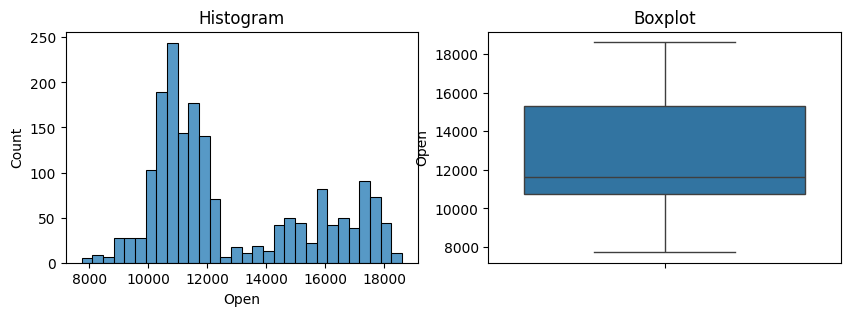

Skewness: 0.6641445382328449
Kurtosis: -0.9894239642814089


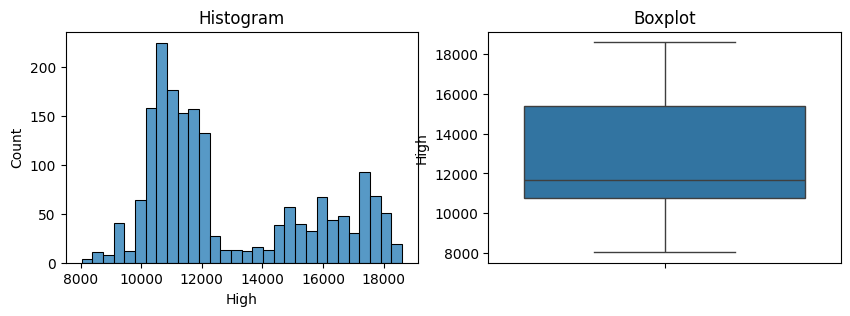

Skewness: 0.6743548231128765
Kurtosis: -1.0034311594001482


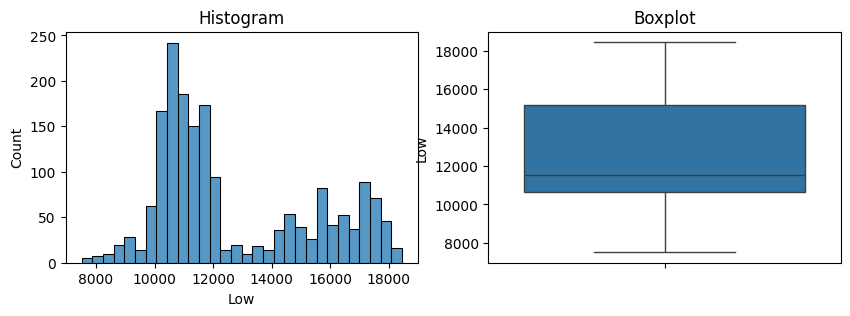

Skewness: 0.6542713569662831
Kurtosis: -0.9764334334341913


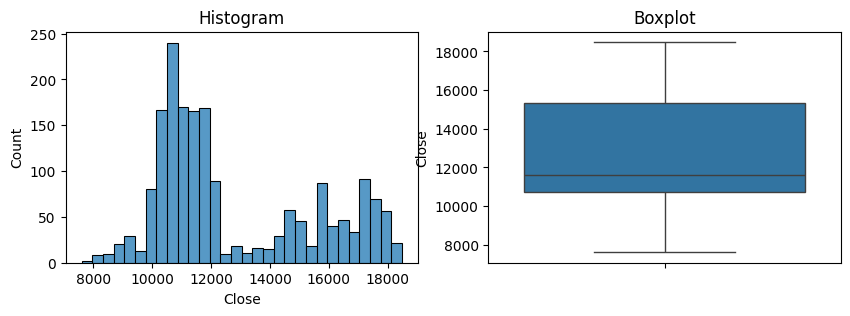

Skewness: 0.6633314077174557
Kurtosis: -0.9923203460247039


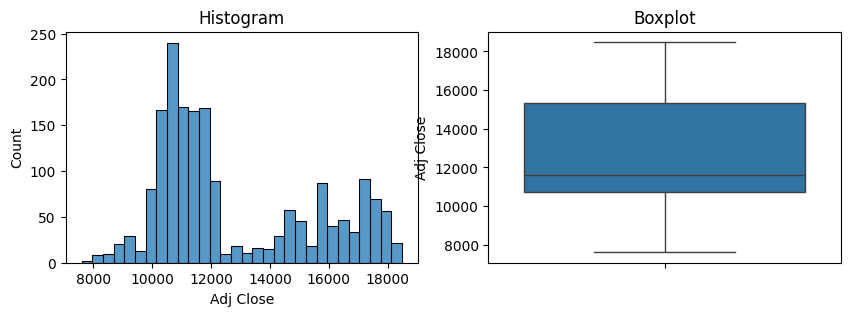

Skewness: 0.6633314077174557
Kurtosis: -0.9923203460247039


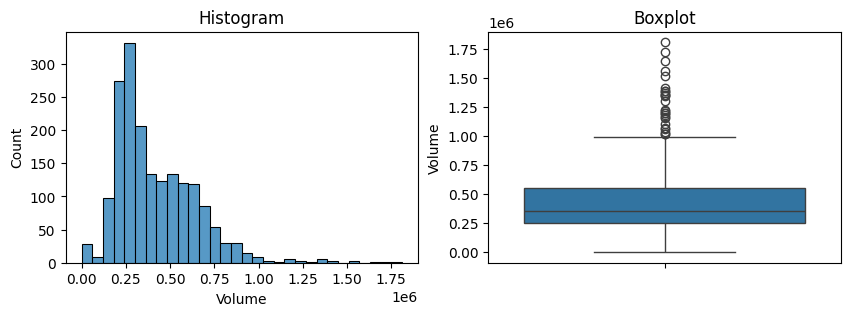

Skewness: 1.3169218223174501
Kurtosis: 3.2896707139162817


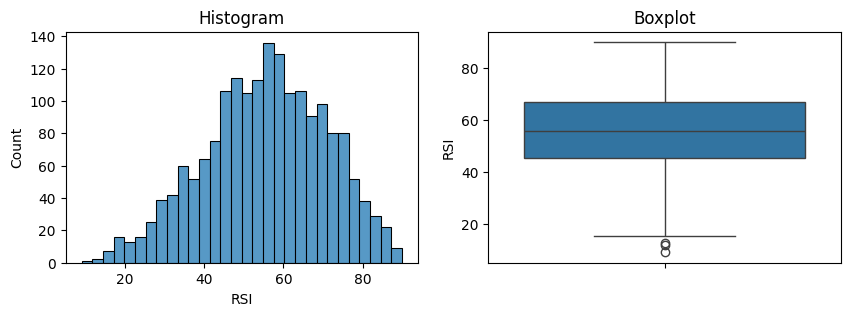

Skewness: -0.226893121570574
Kurtosis: -0.4110530614259966


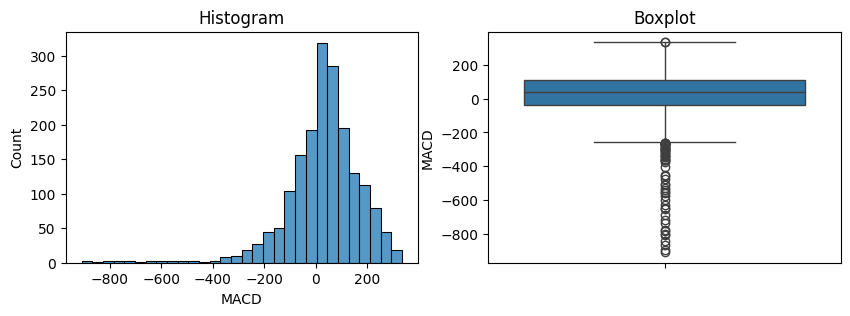

Skewness: -1.6985761881403094
Kurtosis: 7.322781581688852


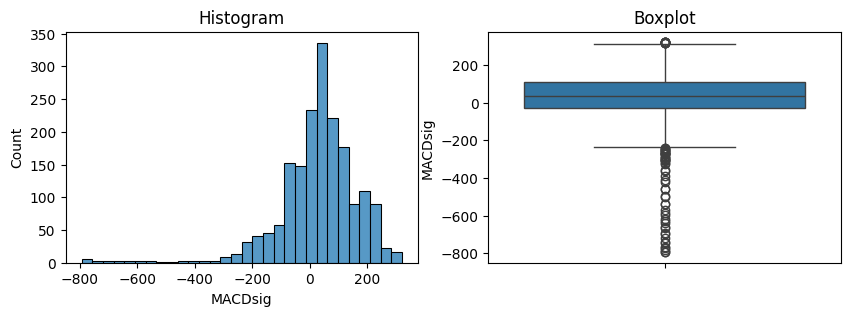

Skewness: -1.7009121925611141
Kurtosis: 7.085407775068538


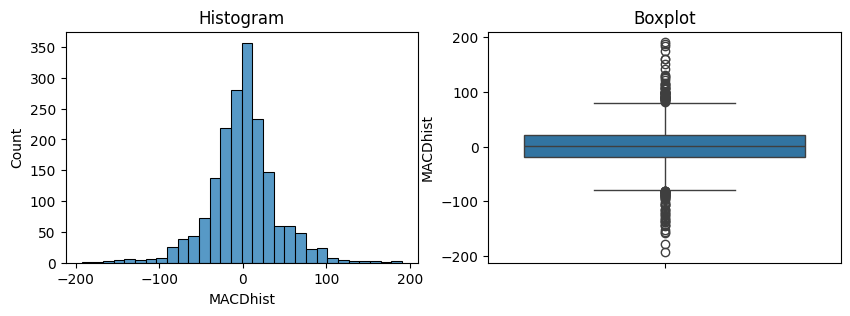

Skewness: 0.031235057012898422
Kurtosis: 2.592729440032773


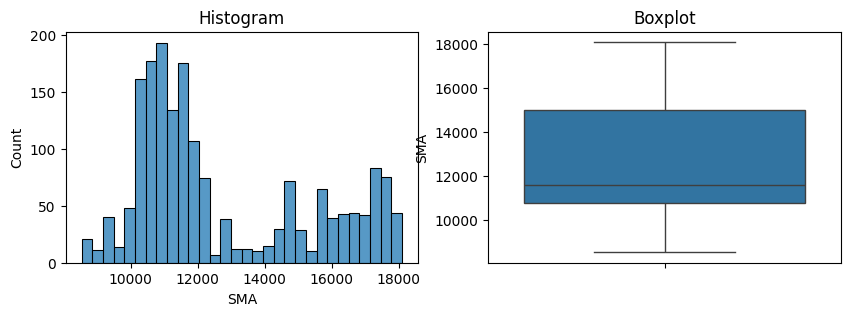

Skewness: 0.6852938800651754
Kurtosis: -0.9773281895432566


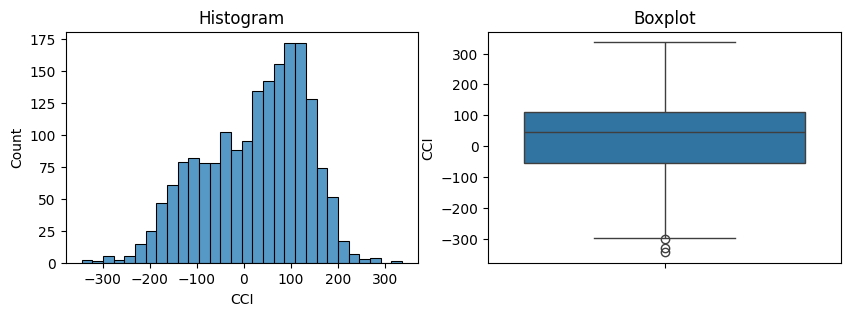

Skewness: -0.4391482995014924
Kurtosis: -0.5136952809305795


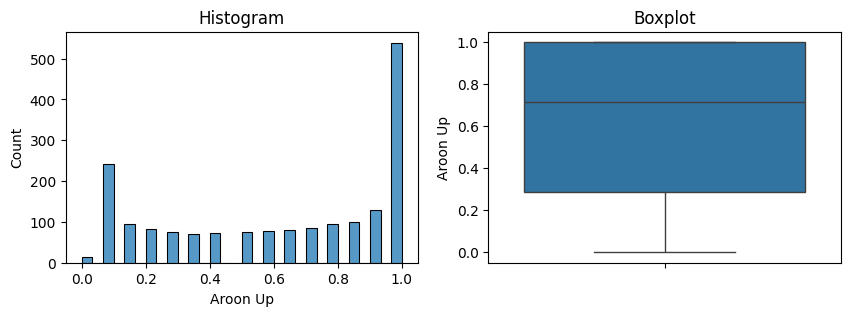

Skewness: -0.36757575078488336
Kurtosis: -1.4202775224984276


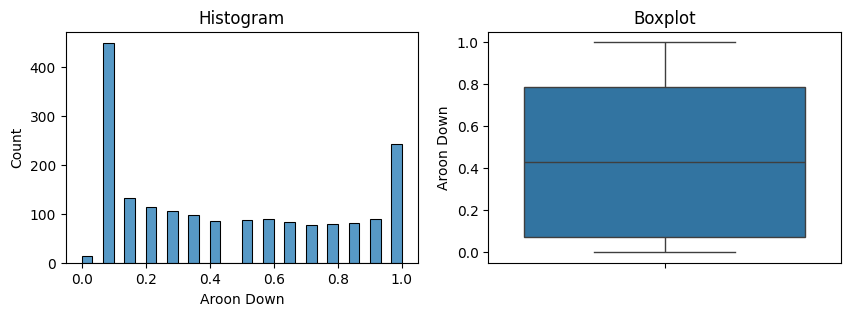

Skewness: 0.3193818362345082
Kurtosis: -1.3887297682593078


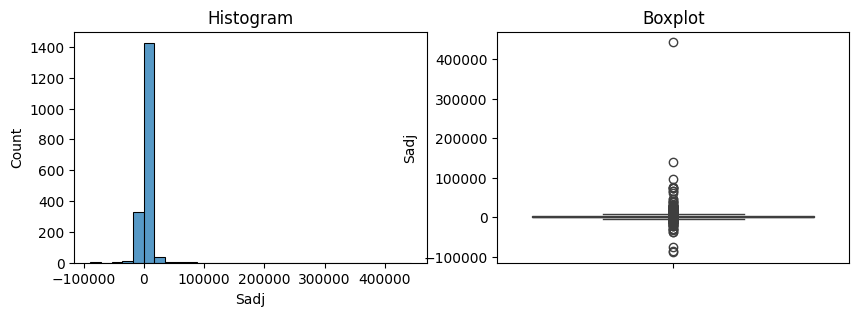

Skewness: 19.092307061893816
Kurtosis: 596.856468379469


In [12]:
def check_distribution_outliers(df, columns):
    for col in columns:
        plt.figure(figsize=(10, 3))

        # Histogram
        plt.subplot(1, 2, 1)
        sns.histplot(df[col], bins=30)
        plt.title('Histogram')

        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(y=df[col])
        plt.title('Boxplot')

        plt.show()

        print('Skewness:', df[col].skew())
        print('Kurtosis:', df[col].kurt())

check_distribution_outliers(df[num_cols], num_cols)

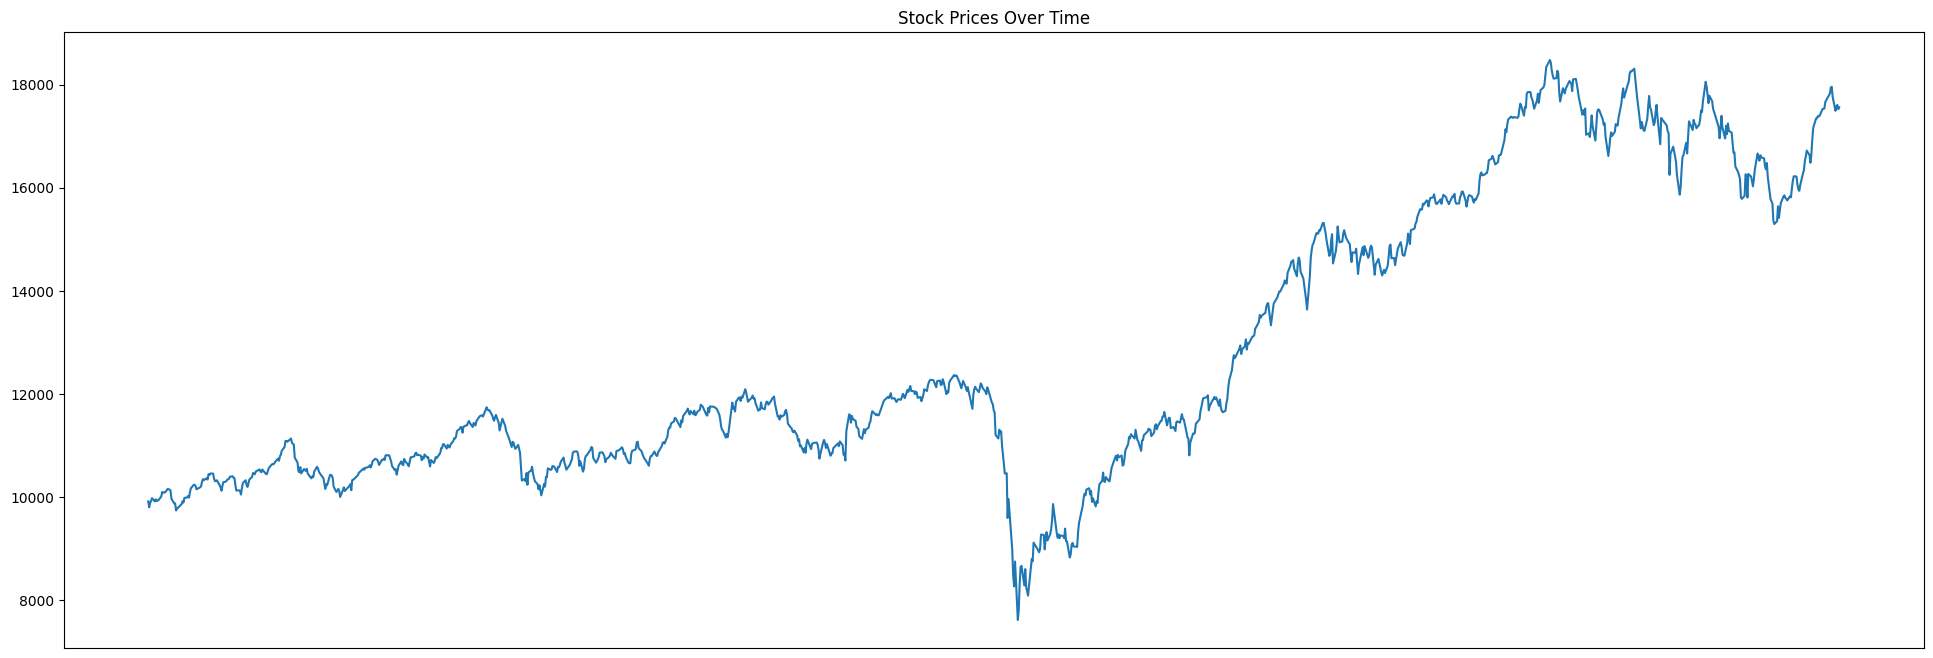

In [13]:
plt.figure(figsize=(24, 8))
plt.plot(df['Date'], df['Close'])
plt.title('Stock Prices Over Time')
plt.xticks([], [])
plt.show()

Seems like a trended series

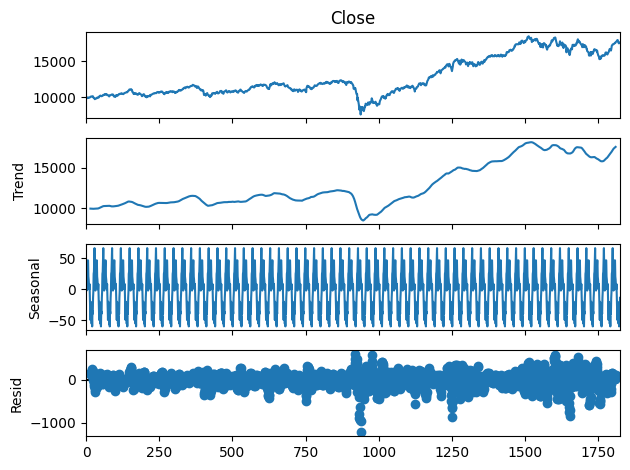

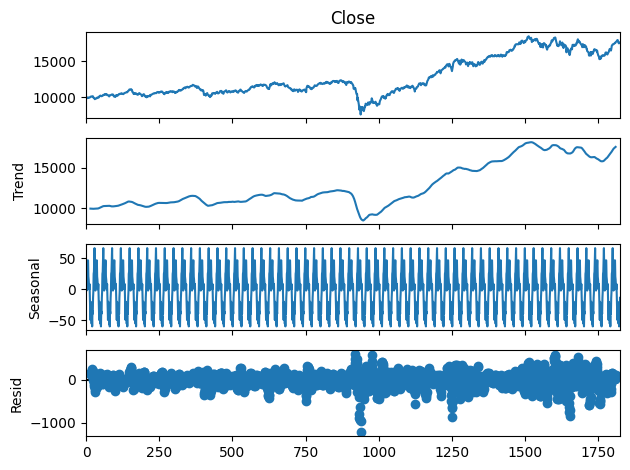

In [14]:
seasonal_decompose(df['Close'], model='additive', period=30).plot()

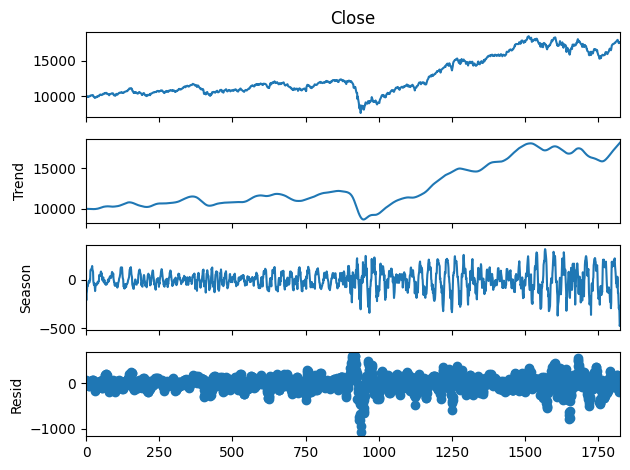

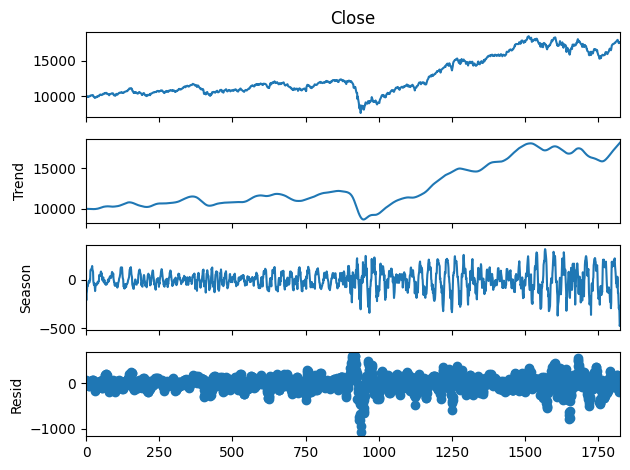

In [15]:
STL(df['Close'], period=30, seasonal=7).fit().plot()

We got a trended series without seasonality. Ideally, we should detrend the data via smoothing. We can also use scalers for that

In [16]:
np.abs(pacf(df['Close'],nlags=365))

array([1.00000000e+00, 9.98680067e-01, 7.03130775e-02, 3.43012949e-02,
       6.88577958e-04, 2.48079685e-02, 1.47807663e-02, 5.65497357e-02,
       4.23953797e-02, 1.20428137e-02, 1.65696394e-02, 9.87924183e-03,
       2.09914619e-02, 5.75337171e-03, 2.21425883e-02, 4.68229365e-02,
       1.04153798e-02, 1.41655839e-02, 6.77222201e-04, 8.26864067e-03,
       3.11933185e-04, 1.53894691e-02, 4.71345401e-03, 4.63846876e-03,
       2.88436831e-02, 6.31300807e-03, 9.94760059e-03, 1.93575864e-02,
       5.28155102e-03, 1.61404648e-03, 1.81394421e-02, 1.25765777e-02,
       2.29792607e-02, 2.29062353e-02, 4.94157411e-03, 5.64032856e-03,
       3.18820469e-02, 5.91676773e-03, 5.18590366e-04, 2.72219899e-02,
       2.69897894e-02, 1.70268469e-02, 2.72965147e-04, 3.03720786e-02,
       1.69775253e-02, 3.72801265e-03, 3.37244810e-03, 1.12859922e-03,
       1.08703815e-02, 5.42492420e-03, 2.08841202e-02, 1.69948193e-03,
       1.58338587e-02, 2.12566494e-02, 3.40107029e-03, 1.85085075e-02,
      

In [17]:
print(np.where(np.abs(pacf(df['Close'],nlags=365))>5e-2)[0])

[  0   1   2   7  68  79 101 103 108 124 149 165 166 184 185 194 197 213
 218 254 263 275 284 304 312 339]


We can set the input window to 7

# Pre-processing

In [44]:
val_size, test_size = 0.1, 0.2

df_train = df[:int(len(df)*(1-val_size-test_size))]
df_val = df[int(len(df)*(1-val_size-test_size)):int(len(df)*(1-test_size))]
df_test = df[int(len(df)*(1-test_size)):]

print(df_train.shape, df_val.shape, df_test.shape)

(1277, 16) (183, 16) (365, 16)


In [45]:
scaler = RobustScaler()
df_train['Close'] = scaler.fit_transform(df_train[['Close']])
df_val['Close'] = scaler.transform(df_val[['Close']])
df_test['Close'] = scaler.transform(df_test[['Close']])

C:\Users\grego\AppData\Local\Temp\ipykernel_13828\3862288697.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['Close'] = scaler.fit_transform(df_train[['Close']])
C:\Users\grego\AppData\Local\Temp\ipykernel_13828\3862288697.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val['Close'] = scaler.transform(df_val[['Close']])
C:\Users\grego\AppData\Local\Temp\ipykernel_13828\3862288697.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

In [47]:
df_train[['Date','Close']].head()

,Date,Close
0,2017-08-28,-0.909072
1,2017-08-29,-1.006421
2,2017-08-30,-0.932752
3,2017-08-31,-0.904819
4,2017-09-01,-0.857708


In [85]:
def generate_windowed_samples(data, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

In [86]:
window_size = 7

x_train, y_train = generate_windowed_samples(df_train['Close'].values, window_size=window_size)
x_val, y_val = generate_windowed_samples(df_val['Close'].values, window_size=window_size)
x_test, y_test = generate_windowed_samples(df_test['Close'].values, window_size=window_size)
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(1270, 7) (1270,)
(176, 7) (176,)
(358, 7) (358,)


In [33]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train,y_train)).batch(32).shuffle(10)
test_ds = tf.data.Dataset.from_tensor_slices((x_test,y_test)).batch(32)
val_ds = tf.data.Dataset.from_tensor_slices((x_val,y_val)).batch(32)

# Univariate Model

In [38]:
inputs = tf.keras.Input(shape=(window_size,1))
model_layers = layers.LSTM(32, activation="tanh", return_state=False, return_sequences=True)(inputs)
model_layers = layers.Dropout(0.2)(model_layers)
out = layers.LSTM(1, activation="linear", return_state=False, return_sequences=False)(model_layers)

model = Model(inputs=inputs, outputs=out)
model.compile(loss = 'MeanSquaredError', metrics=['MAE'], optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 7, 1)]            0         
                                                                 
 lstm_4 (LSTM)               (None, 7, 32)             4352      
                                                                 
 dropout (Dropout)           (None, 7, 32)             0         
                                                                 
 lstm_5 (LSTM)               (None, 1)                 136       
                                                                 
Total params: 4,488
Trainable params: 4,488
Non-trainable params: 0
_________________________________________________________________


In [39]:
history = model.fit(train_ds,validation_data=val_ds,epochs = 20)

Epoch 1/20


40/40 [==============================] - 4s 44ms/step - loss: 0.4407 - MAE: 0.4635 - val_loss: 5.8586 - val_MAE: 2.3635
Epoch 2/20
40/40 [==============================] - 1s 31ms/step - loss: 0.0892 - MAE: 0.1818 - val_loss: 0.5906 - val_MAE: 0.6497
Epoch 3/20
40/40 [==============================] - 1s 30ms/step - loss: 0.0596 - MAE: 0.1842 - val_loss: 0.4144 - val_MAE: 0.5407
Epoch 4/20
40/40 [==============================] - 1s 28ms/step - loss: 0.0454 - MAE: 0.1535 - val_loss: 0.4677 - val_MAE: 0.5871
Epoch 5/20
40/40 [==============================] - 1s 28ms/step - loss: 0.0452 - MAE: 0.1478 - val_loss: 0.2828 - val_MAE: 0.4389
Epoch 6/20
40/40 [==============================] - 1s 28ms/step - loss: 0.0416 - MAE: 0.1435 - val_loss: 0.1243 - val_MAE: 0.2850
Epoch 7/20
40/40 [==============================] - 1s 29ms/step - loss: 0.0405 - MAE: 0.1402 - val_loss: 0.0900 - val_MAE: 0.2458
Epoch 8/20
40/40 [==============================] - 1s 27ms/step - loss: 0.0442 - MAE: 0.1404 

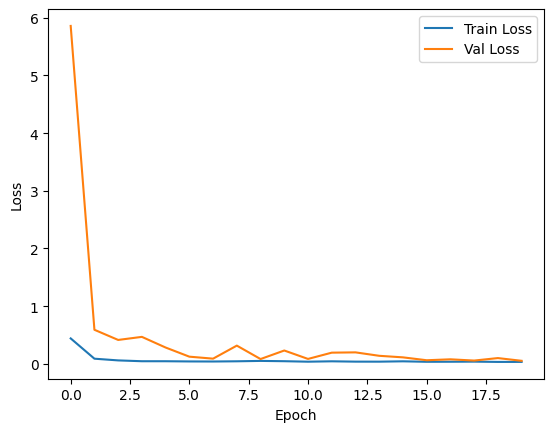

In [40]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(train_loss,label="Train Loss")
plt.plot(val_loss,label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [30]:
y_pred = model.predict(test_ds)
y_pred.shape

(351, 1)

In [29]:
def test_regression_model(test_ds,model,scaler = None):
    y = []
    y_preds = []
    for inputs,labels in test_ds:
        y_pred = model.predict(inputs)
        if scaler:
            labels = scaler.inverse_transform(np.array(labels).reshape(-1, 1))
            y_pred = scaler.inverse_transform(y_pred)
        try:
            y.extend(labels.numpy())
        except:
            y.extend(labels)
        y_preds.extend(y_pred)
    y, y_preds = np.squeeze(y),np.squeeze(y_preds)
    return {'mae': mean_absolute_error(y, y_preds),
            'mse': mean_squared_error(y, y_preds),
            'r2': r2_score(y, y_preds)}

In [41]:
test_regression_model(test_ds,model,scaler)

{'mae': 956.8021697250932,
 'mse': 1131065.9164532789,
 'r2': -1.1643107767101935}

Well, the model wasn't too good, the MSE is quite large and the R2 is negative.

# Multivariate Model

In [153]:
val_size, test_size = 0.1, 0.2

df_train = df[:int(len(df)*(1-val_size-test_size))]
df_val = df[int(len(df)*(1-val_size-test_size)):int(len(df)*(1-test_size))]
df_test = df[int(len(df)*(1-test_size)):]

print(df_train.shape, df_val.shape, df_test.shape)

(1277, 16) (183, 16) (365, 16)


In [152]:
num_cols.remove('Close')

In [154]:
scaler = RobustScaler()
df_train['Close'] = scaler.fit_transform(df_train[['Close']])
df_val['Close'] = scaler.transform(df_val[['Close']])
df_test['Close'] = scaler.transform(df_test[['Close']])

scaler_cov = RobustScaler()
df_train[num_cols] = scaler_cov.fit_transform(df_train[num_cols])
df_val[num_cols] = scaler_cov.transform(df_val[num_cols])
df_test[num_cols] = scaler_cov.transform(df_test[num_cols])

C:\Users\grego\AppData\Local\Temp\ipykernel_13828\3095168405.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['Close'] = scaler.fit_transform(df_train[['Close']])
C:\Users\grego\AppData\Local\Temp\ipykernel_13828\3095168405.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val['Close'] = scaler.transform(df_val[['Close']])
C:\Users\grego\AppData\Local\Temp\ipykernel_13828\3095168405.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

In [109]:
df_train.head()

,Date,Open,High,Low,Close,Adj Close,Volume,RSI,MACD,MACDsig,MACDhist,SMA,CCI,Aroon Up,Aroon Down,Sadj
0,2017-08-28,-0.886058,-0.922106,-0.865733,-0.909072,-0.909072,-0.679967,-0.064469,-0.08546,-0.079962,0.0,1.516201,-0.142838,-1.0,-0.5,NaN
1,2017-08-29,-0.902922,-0.953468,-0.947441,-1.006421,-1.006421,-0.642780,-0.064469,-0.08546,-0.079962,0.0,1.516201,-0.142838,-1.0,-0.5,-0.288360
2,2017-08-30,-0.924784,-0.935418,-0.891680,-0.932752,-0.932752,-0.684853,-0.064469,-0.08546,-0.079962,0.0,1.516201,-0.142838,-1.0,-0.5,-0.349192
3,2017-08-31,-0.887237,-0.922637,-0.886565,-0.904819,-0.904819,-0.223670,-0.064469,-0.08546,-0.079962,0.0,1.516201,-0.142838,-1.0,-0.5,-0.344821
4,2017-09-01,-0.861271,-0.874982,-0.842572,-0.857708,-0.857708,-0.684853,-0.064469,-0.08546,-0.079962,0.0,1.516201,-0.142838,-1.0,-0.5,1.392361


In [155]:
df_train = df_train.drop(columns=['Date','Sadj'])
df_val = df_val.drop(columns=['Date','Sadj'])
df_test = df_test.drop(columns=['Date','Sadj'])

In [156]:
df_train.loc[0:7].to_numpy().shape

(8, 14)

In [157]:
def generate_windowed_samples(data, window_size=30, out_col='Close'):
    data = data.copy().reset_index(drop=True)
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data.loc[i:i + window_size-1].to_numpy())
        y.append(data.loc[i + window_size,out_col])
    return np.array(X), np.array(y)

In [158]:
window_size = 7

x_train, y_train = generate_windowed_samples(df_train, window_size=window_size)
x_val, y_val = generate_windowed_samples(df_val, window_size=window_size)
x_test, y_test = generate_windowed_samples(df_test, window_size=window_size)
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(1270, 7, 14) (1270,)
(176, 7, 14) (176,)
(358, 7, 14) (358,)


In [159]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train,y_train)).batch(32).shuffle(10)
test_ds = tf.data.Dataset.from_tensor_slices((x_test,y_test)).batch(32)
val_ds = tf.data.Dataset.from_tensor_slices((x_val,y_val)).batch(32)

In [184]:
inputs = tf.keras.Input(shape=(window_size,x_train.shape[-1]))
model_layers = layers.GRU(256, activation="tanh", return_state=False, return_sequences=True)(inputs)
model_layers = layers.Dropout(0.2)(model_layers)
model_layers = layers.GRU(64, activation="tanh", return_state=False, return_sequences=False)(model_layers)
model_layers = layers.Dropout(0.2)(model_layers)
out = layers.Dense(1, activation="linear")(model_layers)

model = Model(inputs=inputs, outputs=out)
model.compile(loss = 'MeanSquaredError', metrics=['MAE'], optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))
model.summary()

Model: "model_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_13 (InputLayer)       [(None, 7, 14)]           0         
                                                                 
 gru_11 (GRU)                (None, 7, 256)            208896    
                                                                 
 dropout_12 (Dropout)        (None, 7, 256)            0         
                                                                 
 gru_12 (GRU)                (None, 64)                61824     
                                                                 
 dropout_13 (Dropout)        (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 270,785
Trainable params: 270,785
Non-traina

In [185]:
history = model.fit(train_ds,validation_data=val_ds,epochs = 20)

Epoch 1/20


40/40 [==============================] - 3s 30ms/step - loss: 0.1222 - MAE: 0.2628 - val_loss: 0.9272 - val_MAE: 0.9382
Epoch 2/20
40/40 [==============================] - 1s 14ms/step - loss: 0.0987 - MAE: 0.2398 - val_loss: 0.5875 - val_MAE: 0.7404
Epoch 3/20
40/40 [==============================] - 0s 12ms/step - loss: 0.1019 - MAE: 0.2427 - val_loss: 0.3685 - val_MAE: 0.5395
Epoch 4/20
40/40 [==============================] - 0s 11ms/step - loss: 0.0801 - MAE: 0.1965 - val_loss: 0.1823 - val_MAE: 0.3716
Epoch 5/20
40/40 [==============================] - 0s 11ms/step - loss: 0.0598 - MAE: 0.1875 - val_loss: 0.0518 - val_MAE: 0.1892
Epoch 6/20
40/40 [==============================] - 0s 11ms/step - loss: 0.0383 - MAE: 0.1279 - val_loss: 0.0603 - val_MAE: 0.1987
Epoch 7/20
40/40 [==============================] - 0s 11ms/step - loss: 0.0289 - MAE: 0.1156 - val_loss: 0.0582 - val_MAE: 0.1924
Epoch 8/20
40/40 [==============================] - 1s 13ms/step - loss: 0.0271 - MAE: 0.1169 

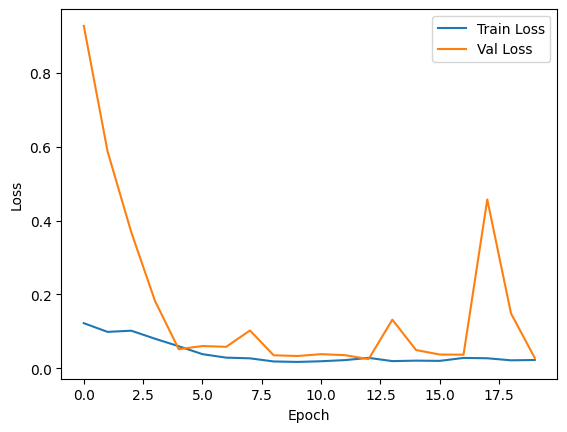

In [186]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(train_loss,label="Train Loss")
plt.plot(val_loss,label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [177]:
def test_regression_model(test_ds,model,scaler = None):
    y = []
    y_preds = []
    for inputs,labels in test_ds:
        y_pred = model.predict(inputs)
        if scaler:
            labels = scaler.inverse_transform(np.array(labels).reshape(-1,1))
            y_pred = scaler.inverse_transform(y_pred)
        try:
            y.extend(labels.numpy())
        except:
            y.extend(labels)
        y_preds.extend(y_pred)
    y, y_preds = np.squeeze(y),np.squeeze(y_preds)
    return {'mae': mean_absolute_error(y, y_preds),
            'mse': mean_squared_error(y, y_preds),
            'r2': r2_score(y, y_preds)}

In [187]:
test_regression_model(test_ds,model,scaler)

{'mae': 714.7211577820648, 'mse': 640019.377319812, 'r2': -0.22468621455788984}

The model got better! However, we still can't determine why. Solution: Grid Search!